# Visualização de uma captura convertida

Este notebook abre um arquivo NPZ convertido e plota gráficos de visualização.

## 1. Carregamento

O arquivo convertido fica em `capture_data/converted_npz/files`.
Na célula de carregamento, altere somente `NOME_ARQUIVO_NPZ` para o nome do seu arquivo.

In [1]:
from pathlib import Path
import sys

PROJETO = Path.cwd().parent if Path.cwd().name == "examples" else Path.cwd()
if str(PROJETO) not in sys.path:
    sys.path.insert(0, str(PROJETO))

from mvnview import MocapData
from mvnview.dguv import RULES
from mvnview.primary_plots import (
    plot_flat_segment_position,
    plot_segment_acceleration_components,
    plot_segment_position,
    plot_segment_scalar_acceleration,
    plot_segment_scalar_velocity,
    plot_segment_velocity_components,
    plot_abduction_byframe,
    plot_rotation_byframe,
    plot_flexion_byframe,
    plot_abduction_histogram,
    plot_rotation_histogram,
    plot_flexion_histogram,
)

PASTA_ARQUIVOS_NPZ = PROJETO / "capture_data" / "converted_npz" / "files"
NOME_ARQUIVO_NPZ = "captura_de_movimento_convertida.npz"
arquivo_npz_convertido = PASTA_ARQUIVOS_NPZ / NOME_ARQUIVO_NPZ

if not arquivo_npz_convertido.exists():
    raise FileNotFoundError(
        f"Arquivo não encontrado: {arquivo_npz_convertido}. "
        "Execute primeiro o notebook de análise ou confira o nome do arquivo."
    )

dados_captura = MocapData(arquivo_npz_convertido)
print(f"Arquivo carregado: {arquivo_npz_convertido.name}")

Arquivo carregado: captura_de_movimento_convertida.npz


## 2. Gráfico da trajetória

As funções de `primary_plots` recebem os dados e o nome do segmento.

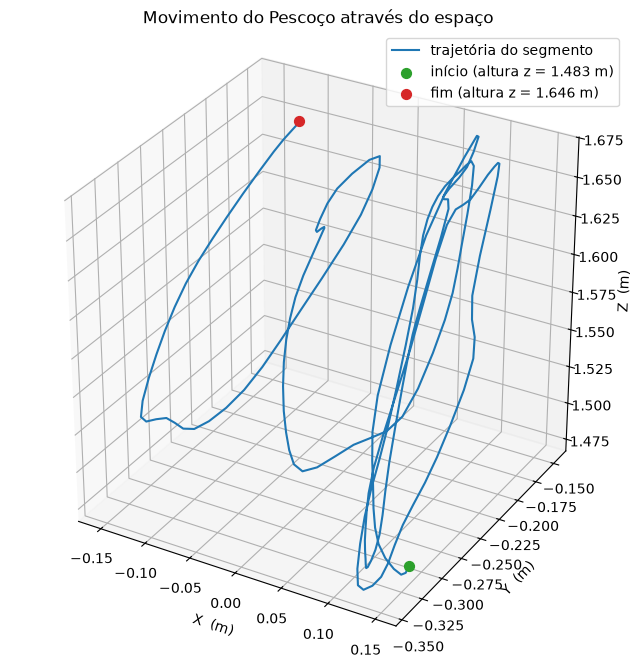

In [2]:
segmento_para_graficos = "Neck"
junta_para_graficos = "jT1C7"
regra_abducao = RULES["head_lateral_inclination"]
regra_rotacao = RULES["neck_torsion"]
regra_flexao = RULES["neck_bending"].mirrored()
plot_segment_position(dados_captura, segmento_para_graficos, "Movimento do Pescoço através do espaço")

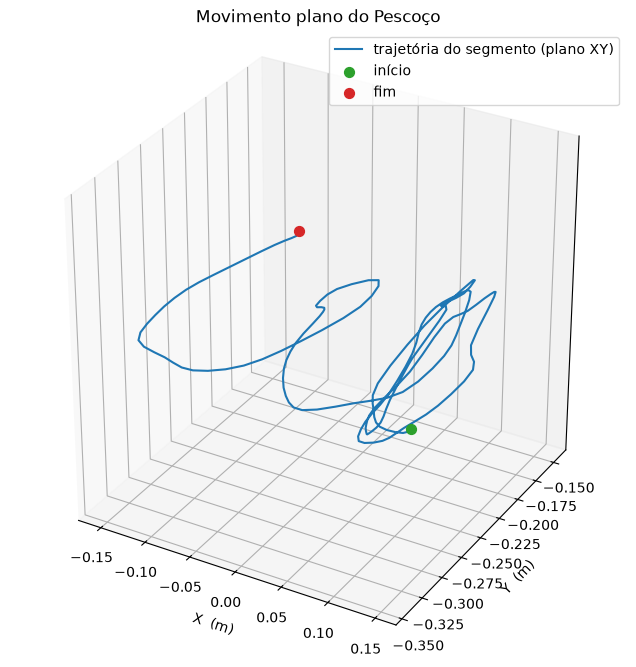

In [3]:
plot_flat_segment_position(dados_captura, segmento_para_graficos, "Movimento plano do Pescoço")

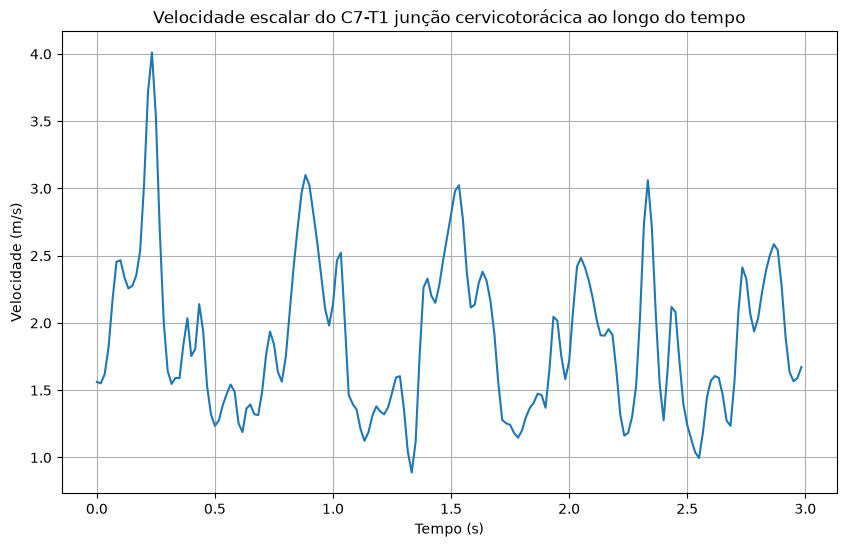

In [4]:
plot_segment_scalar_velocity(dados_captura, segmento_para_graficos, "Velocidade escalar do C7-T1 junção cervicotorácica ao longo do tempo")

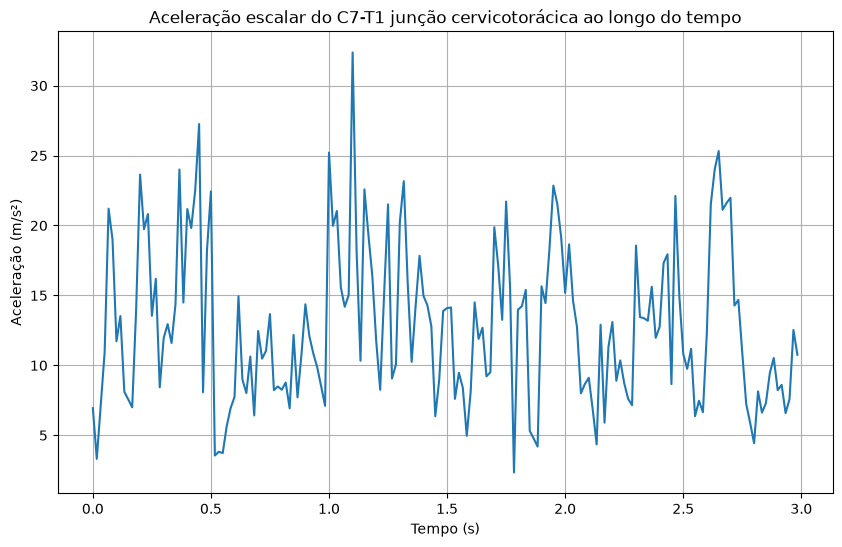

In [5]:
plot_segment_scalar_acceleration(dados_captura, segmento_para_graficos, "Aceleração escalar do C7-T1 junção cervicotorácica ao longo do tempo")

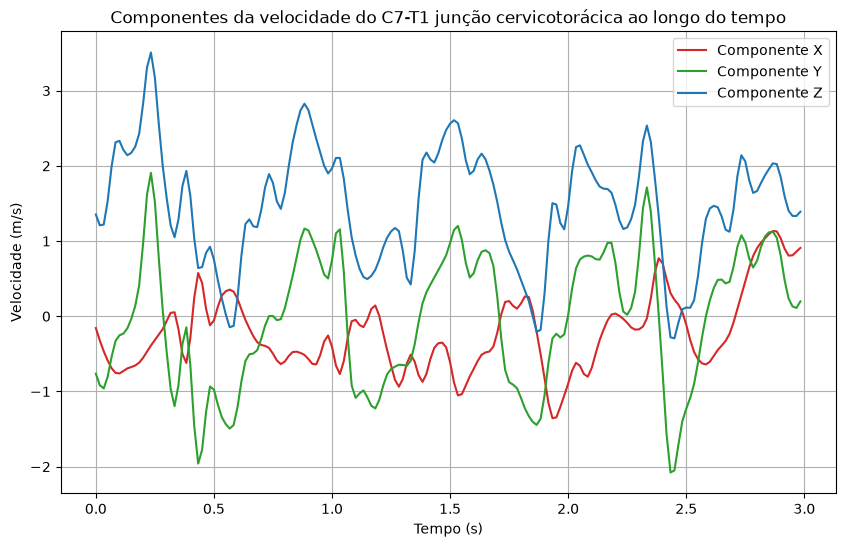

In [6]:
plot_segment_velocity_components(dados_captura, segmento_para_graficos, "Componentes da velocidade do C7-T1 junção cervicotorácica ao longo do tempo")

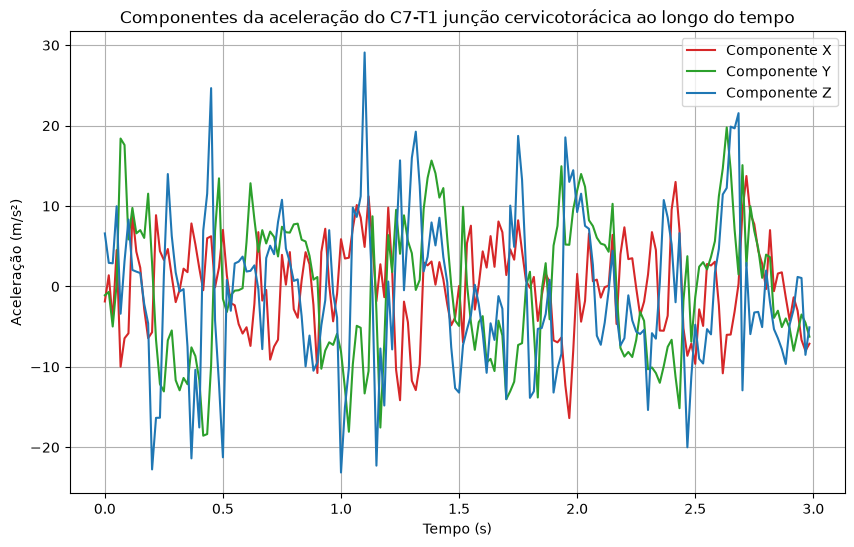

In [7]:
plot_segment_acceleration_components(dados_captura, segmento_para_graficos, "Componentes da aceleração do C7-T1 junção cervicotorácica ao longo do tempo")

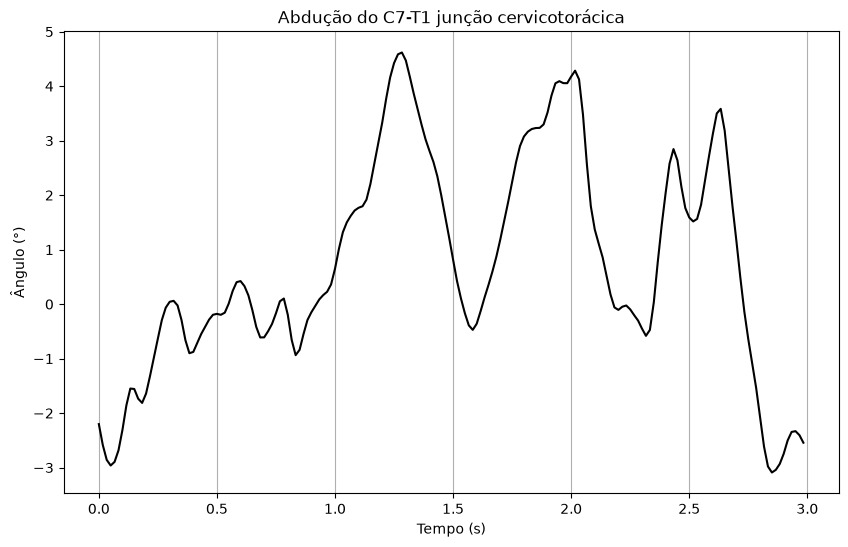

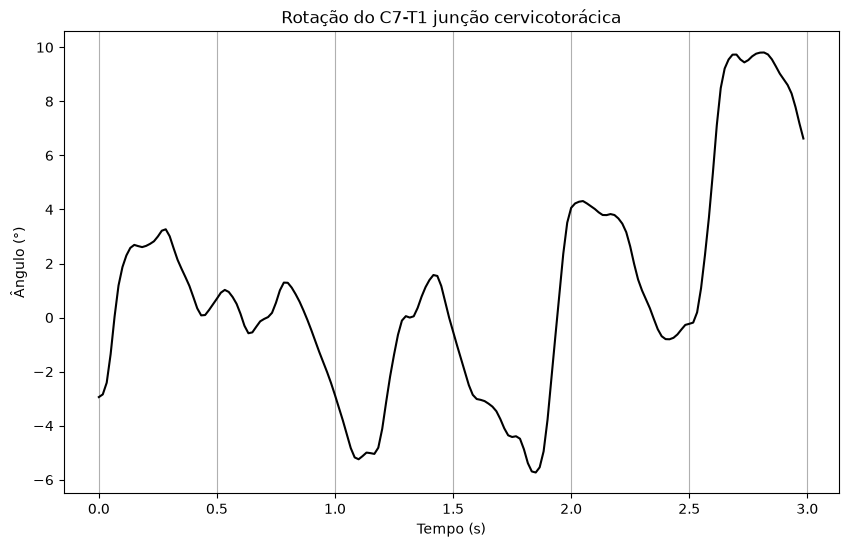

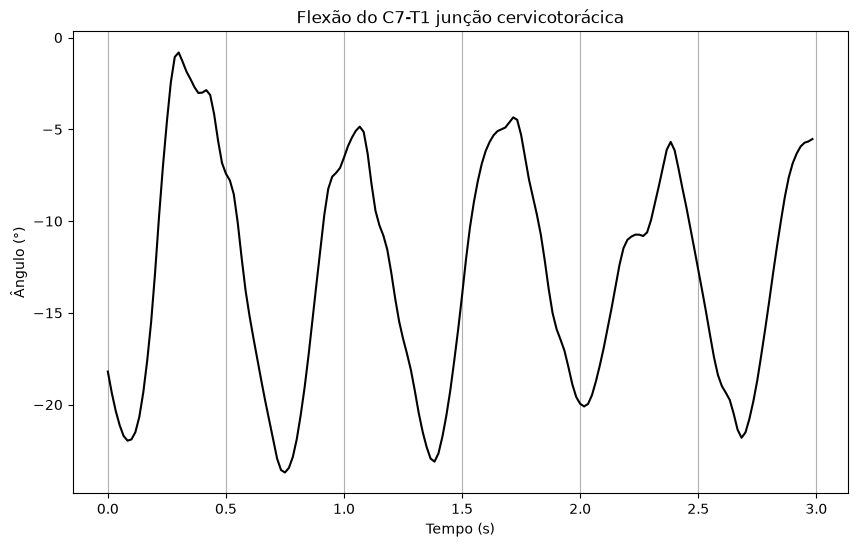

In [29]:
plot_abduction_byframe(
    dados_captura,
    junta_para_graficos,
    'Abdução do C7-T1 junção cervicotorácica',
    #rule=regra_abducao,
)
plot_rotation_byframe(
    dados_captura,
    junta_para_graficos,
    'Rotação do C7-T1 junção cervicotorácica',
    #rule=regra_rotacao,
)
plot_flexion_byframe(
    dados_captura,
    junta_para_graficos,
    'Flexão do C7-T1 junção cervicotorácica',
    #rule=regra_flexao,
)

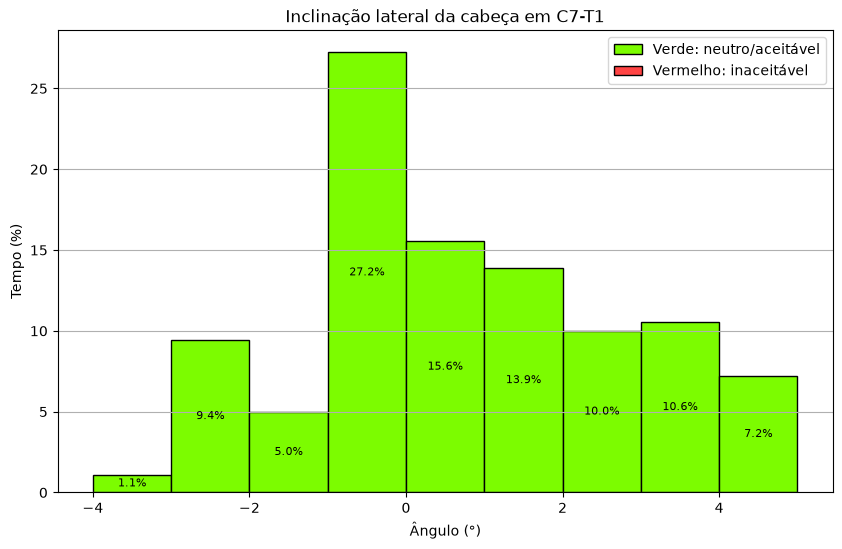

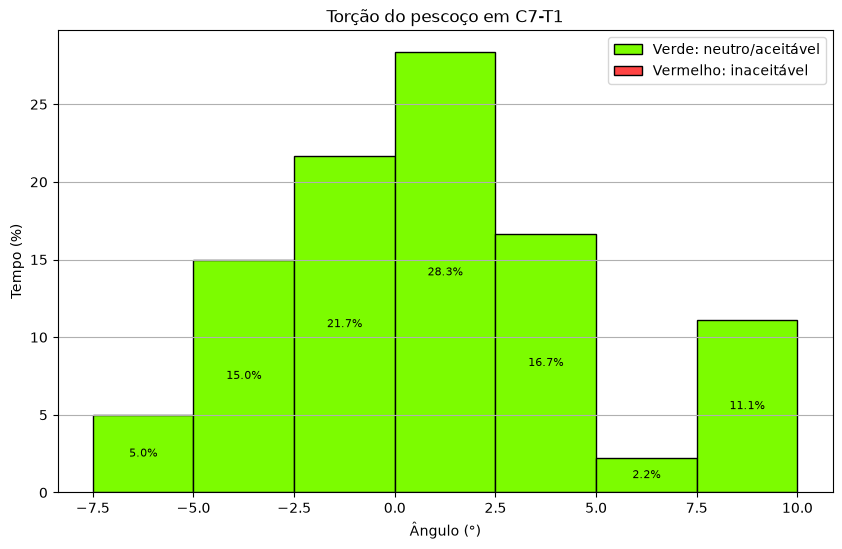

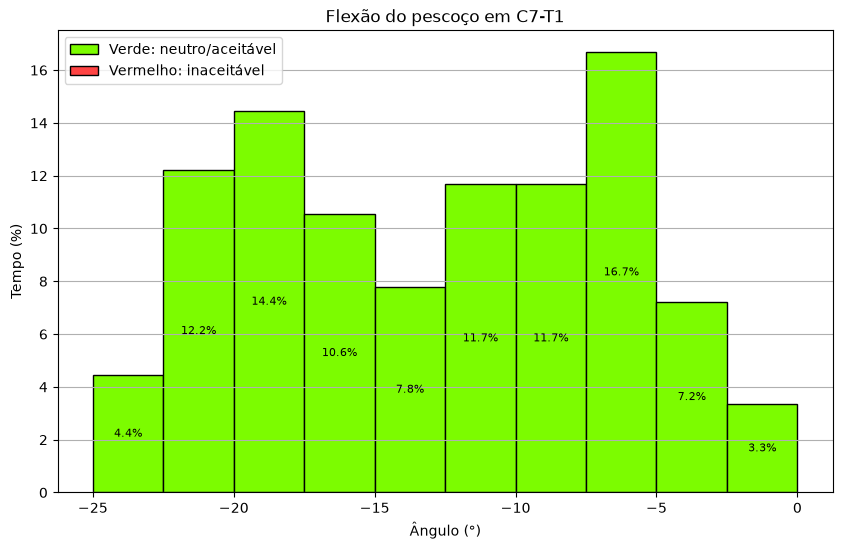

In [9]:
num_bins = 8
plot_abduction_histogram(
    dados_captura,
    junta_para_graficos,
    num_bins,
    'Inclinação lateral da cabeça em C7-T1',
    rule=regra_abducao,
)
plot_rotation_histogram(
    dados_captura,
    junta_para_graficos,
    num_bins,
    'Torção do pescoço em C7-T1',
    rule=regra_rotacao,
)
plot_flexion_histogram(
    dados_captura,
    junta_para_graficos,
    num_bins,
    'Flexão do pescoço em C7-T1',
    rule=regra_flexao,
)

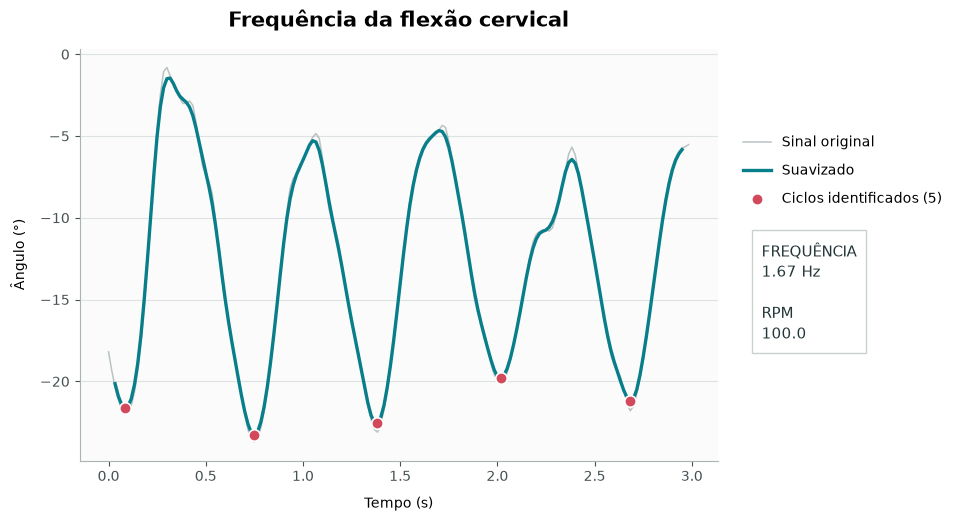

In [27]:
import numpy as np
import matplotlib.pyplot as plt

fps = 60.0
angulo_flexao = np.asarray(
    dados_captura.get_joint_angle(junta_para_graficos)[:, 2],
    dtype=float,
)
tempo = np.arange(angulo_flexao.size) / fps

sinal_centralizado = angulo_flexao - np.mean(angulo_flexao)
fft_valores = np.abs(np.fft.rfft(sinal_centralizado))
frequencias = np.fft.rfftfreq(angulo_flexao.size, d=1 / fps)
frequencia_hz = frequencias[np.argmax(fft_valores)]
rpm = frequencia_hz * 60

janela_suavizacao = 5
suavizado = np.convolve(
    angulo_flexao,
    np.ones(janela_suavizacao) / janela_suavizacao,
    mode="valid",
)
tempo_suavizado = np.arange(
    janela_suavizacao // 2,
    angulo_flexao.size - janela_suavizacao // 2,
) / fps

candidatos = np.flatnonzero(
    (suavizado[1:-1] <= suavizado[:-2])
    & (suavizado[1:-1] < suavizado[2:])
) + 1
candidatos = candidatos[suavizado[candidatos] <= np.percentile(suavizado, 30)]
distancia_minima_frames = int(0.35 * fps)
vales = []
for candidato in sorted(candidatos, key=lambda indice: suavizado[indice]):
    if all(abs(candidato - vale) >= distancia_minima_frames for vale in vales):
        vales.append(candidato)
vales = np.array(sorted(vales))
tempo_vales = tempo_suavizado[vales]

fig, ax = plt.subplots(figsize=(11, 5.8), facecolor="white")
ax.set_facecolor("#FAFBFA")
ax.plot(
    tempo,
    angulo_flexao,
    color="#AAB4B5",
    linewidth=1.1,
    alpha=0.8,
    label="Sinal original",
)
ax.plot(
    tempo_suavizado,
    suavizado,
    color="#087E8B",
    linewidth=2.4,
    label="Suavizado",
)
ax.scatter(
    tempo_vales,
    suavizado[vales],
    color="#D1495B",
    edgecolor="white",
    linewidth=1.2,
    s=68,
    zorder=3,
    label=f"Ciclos identificados ({vales.size})",
)
ax.set_title("Frequência da flexão cervical", loc="center", fontsize=15, fontweight="bold", pad=16)
ax.set_xlabel("Tempo (s)", labelpad=9)
ax.set_ylabel("Ângulo (°)", labelpad=9)
ax.grid(axis="y", color="#DDE3E2", linewidth=0.8)
ax.grid(axis="x", visible=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#AAB4B5")
ax.spines["bottom"].set_color("#AAB4B5")
ax.tick_params(colors="#465254")
ax.legend(
    loc="upper left",
    bbox_to_anchor=(1.02, 0.82),
    frameon=False,
    fontsize=10,
    labelspacing=1.0,
)
fig.subplots_adjust(left=0.10, right=0.68, top=0.86, bottom=0.15)
fig.text(
    0.72,
    0.53,
    f"FREQUÊNCIA\n{frequencia_hz:.2f} Hz\n\nRPM\n{rpm:.1f}",
    ha="left",
    va="top",
    fontsize=11,
    linespacing=1.35,
    color="#243638",
    bbox={
        "boxstyle": "square,pad=0.65",
        "facecolor": "white",
        "edgecolor": "#C8D1D0",
        "linewidth": 1.0,
    },
)
plt.show()